# Baseline Cointegration Anslysis

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.stattools import coint

In [20]:
df = pd.read_csv("../data/pep_ko_daily.csv", index_col=0)

## Regression

To test that two time series $X_t$ and $Y_t$ are cointigrated, we must use the Engle Granger test (`statsmodels.tsa.stattools.coint`). The null and alternative hypotheses are as follows:
$$ H_0: \text{$X_t$ and $Y_t$ are not cointigrated}$$
$$ H_1: \text{$X_t$ and $Y_t$ are cointigrated}$$

By cointegration, we mean that when we regress $X_t$ on $Y_t$ using OLS, or vice versa, the residuals are stationary.

This test is infamously not symmetric, and a result may hold if $X_t$ is regressed on $Y_t$ but not the other way around. To mitigate for this, we will do the test both ways around to check for any 'disagreements'.

In [22]:
model_ko_pep = sm.OLS(df['close_pep'], sm.add_constant(df['close_ko']))
results_ko_pep = model_ko_pep.fit()

model_pep_ko = sm.OLS(df['close_ko'], sm.add_constant(df['close_pep']))
results_pep_ko = model_pep_ko.fit()

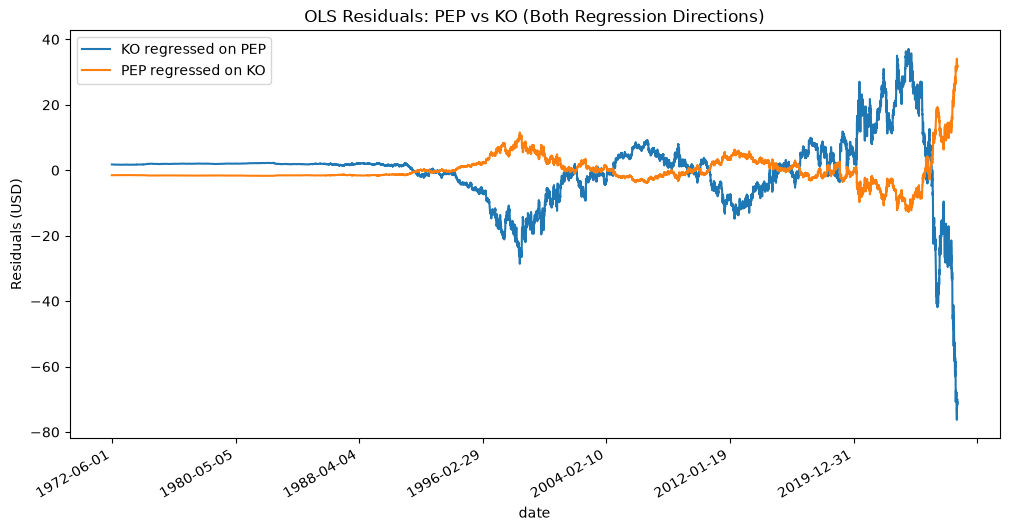

In [30]:
plt.figure(figsize=(12, 6))

results_ko_pep.resid.plot(label="KO regressed on PEP")
results_pep_ko.resid.plot(label="PEP regressed on KO")

plt.title("OLS Residuals: PEP vs KO (Both Regression Directions)")
plt.ylabel("Residuals (USD)")
plt.legend()

plt.gcf().autofmt_xdate()

plt.show()

In [24]:
_, pvalue_ko_pep, _ = coint(df['close_ko'], df['close_pep'])
_, pvalue_pep_ko, _ = coint(df['close_pep'], df['close_ko'])

In [35]:
print("KO regressed on PEP - Cointegration identified: ", pvalue_ko_pep<=0.05, "\np-value: ", pvalue_ko_pep, "\n")
print("PEP regressed on KO - Cointegration identified: ", pvalue_pep_ko<=0.05, "\np-value: ", pvalue_pep_ko)

KO regressed on PEP - Cointegration identified:  False 
p-value:  0.9857284606424307 

PEP regressed on KO - Cointegration identified:  False 
p-value:  0.9510748741240085
